# 1. Importación de bibliotecas

Importamos las bibliotecas necesarias parra poder analizar y visualizar los datos de manera correcta.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_data = pd.read_csv("../data/develop_dataset_2025_limpio.csv", index_col=0)

In [18]:
# 1. Tipificar los datos

numeric_cols = df_data.select_dtypes(include="number").columns
categorical_cols = df_data.select_dtypes(include=["object", "string", "category"]).columns

print("Variables numéricas:")
print(numeric_cols)

print("\nVariables categóricas:")
print(categorical_cols)

Variables numéricas:
Index(['ConvertedCompYearly', 'WorkExp', 'YearsCode', 'JobSat'], dtype='str')

Variables categóricas:
Index(['Age', 'EdLevel', 'Employment', 'AISelect', 'Industry', 'Country',
       'DevType'],
      dtype='str')


En este paso se han tipificado las variables del dataset según su tipo de dato. Se identifican cuatro variables numéricas: `ConvertedCompYearly`, `WorkExp`, `YearsCode` y `JobSat`, que permiten calcular medidas estadísticas como media, mediana, dispersión y rangos.

Por otro lado, se identifican siete variables categóricas: `Age`, `EdLevel`, `Employment`, `AISelect`, `Industry`, `Country` y `DevType`. Estas variables representan categorías o grupos, por lo que se analizarán mediante frecuencias, porcentajes y gráficos de barras.

La variable `Age` se considera categórica porque está expresada en rangos de edad y no como una edad numérica exacta.

In [19]:
# 2. Tendencia central de variables numéricas
df_data[numeric_cols].agg(["mean", "median", "min", "max"])


,ConvertedCompYearly,WorkExp,YearsCode,JobSat
mean,1.019077e+05,12.421113,15.764773,7.227731
median,8.000000e+04,10.000000,13.000000,8.000000
min,1.000000e+00,1.000000,1.000000,0.000000
max,4.706124e+06,50.000000,100.000000,10.000000


In [20]:
# Revisar valores extremos en salario
df_data.sort_values("ConvertedCompYearly", ascending=False)[
    ["ConvertedCompYearly", "Country", "DevType", "WorkExp", "YearsCode"]
].head(10)
# Revisar salarios más bajos
df_data.sort_values("ConvertedCompYearly", ascending=True)[
    ["ConvertedCompYearly", "Country", "DevType", "WorkExp", "YearsCode"]
].head(10)
# Revisar valores extremos en YearsCode
df_data.sort_values("YearsCode", ascending=False)[
    ["YearsCode", "Age", "WorkExp", "DevType", "Country"]
].head(10)

,YearsCode,Age,WorkExp,DevType,Country
37119,100.0,25-34 years old,3.0,Data engineer,Italy
29050,100.0,18-24 years old,10.0,Data or business analyst,Ethiopia
17793,60.0,65 years or older,25.0,AI/ML engineer,United States of America
2846,58.0,65 years or older,20.0,Applied scientist,United States of America
40129,57.0,65 years or older,47.0,Data scientist,United Kingdom of Great Britain and Northern I...
41415,55.0,65 years or older,40.0,Data scientist,United States of America
35208,53.0,55-64 years old,43.0,Data scientist,United States of America
16716,52.0,65 years or older,45.0,Applied scientist,Canada
5273,50.0,65 years or older,45.0,AI/ML engineer,United States of America
39942,50.0,65 years or older,43.0,Applied scientist,United States of America


En esta primera revisión se observan posibles valores anómalos en algunas variables numéricas. En `ConvertedCompYearly`, el valor mínimo de 1 y el máximo de 4.706.124 parecen extremos para una compensación anual, por lo que se analizarán posteriormente como posibles outliers. También destaca `YearsCode`, con un máximo de 100 años, valor que parece poco realista y requiere revisión.

Por el momento no se eliminan registros, ya que primero se analizará su impacto mediante gráficos de caja, histogramas y detección de outliers.

In [21]:
# Limpieza inicial previa al análisis univariante

df_data_clean = df_data.copy()

# Corregir valores claramente anómalos en YearsCode
df_data_clean.loc[df_data_clean["YearsCode"] == 100, "YearsCode"] = pd.NA

# Comprobar el resultado después de la limpieza
df_data_clean["YearsCode"].describe()

count    1741.000000
mean       15.668007
std        10.498279
min         1.000000
25%         8.000000
50%        13.000000
75%        20.000000
max        60.000000
Name: YearsCode, dtype: float64

Tras revisar la variable `YearsCode`, se detectaron dos registros con un valor de 100 años programando, incompatibles con el rango de edad declarado. Estos valores se sustituyeron por nulos, manteniendo el resto de información de los registros.

Después de la limpieza, la variable presenta 1741 valores válidos, una media de 15,67 años, una mediana de 13 años y un máximo de 60 años, valores más coherentes para el análisis.

In [22]:
# 3. Tendencia central de variables categóricas
# En categóricas usamos la moda: el valor más frecuente

for col in categorical_cols:
    print(f"\nVariable: {col}")
    print("Moda:")
    print(df_data_clean[col].mode())


Variable: Age
Moda:
0    25-34 years old
Name: Age, dtype: str

Variable: EdLevel
Moda:
0    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)
Name: EdLevel, dtype: str

Variable: Employment
Moda:
0    Employed
Name: Employment, dtype: str

Variable: AISelect
Moda:
0    Yes
Name: AISelect, dtype: str

Variable: Industry
Moda:
0    Software Development
Name: Industry, dtype: str

Variable: Country
Moda:
0    United States of America
Name: Country, dtype: str

Variable: DevType
Moda:
0    Data engineer
Name: DevType, dtype: str


En las variables categóricas, la medida de tendencia central utilizada es la moda, ya que representa la categoría más frecuente de cada variable.

Los resultados muestran que el perfil más habitual del dataset corresponde a personas de 25-34 años, con nivel educativo de máster, empleadas, que han respondido afirmativamente a `AISelect`, pertenecientes principalmente a la industria de desarrollo de software, procedentes de Estados Unidos y con perfil profesional de Data engineer.


Variable categórica: Age
Age
25-34 years old      687
35-44 years old      513
45-54 years old      249
18-24 years old      167
55-64 years old      100
65 years or older     26
Prefer not to say      1
Name: count, dtype: int64

Porcentajes:
Age
25-34 years old      39.41
35-44 years old      29.43
45-54 years old      14.29
18-24 years old       9.58
55-64 years old       5.74
65 years or older     1.49
Prefer not to say     0.06
Name: proportion, dtype: float64


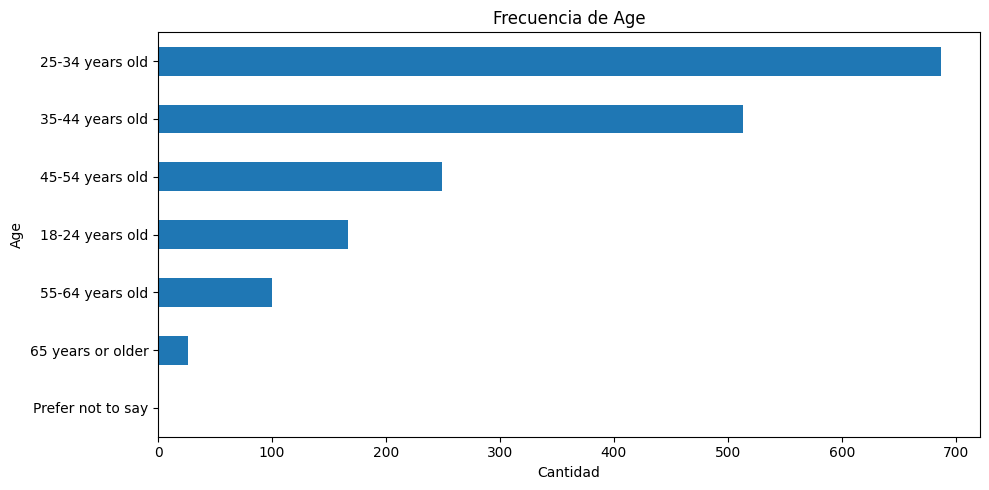


Variable categórica: EdLevel
EdLevel
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       715
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          554
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        275
Some college/university study without earning a degree                                101
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     46
Associate degree (A.A., A.S., etc.)                                                    30
Other (please specify):                                                                13
Primary/elementary school                                                               9
Name: count, dtype: int64

Porcentajes:
EdLevel
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       41.02
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          31.78
Profession

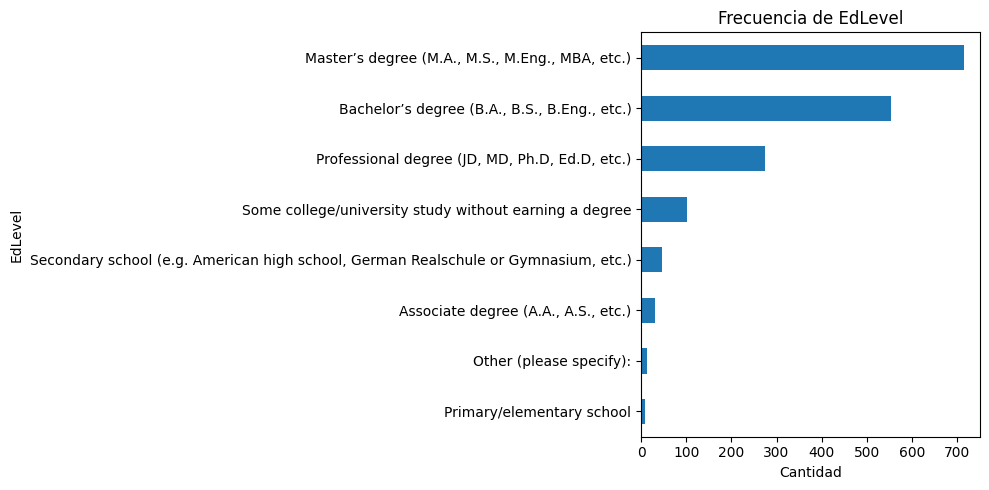


Variable categórica: Employment
Employment
Employed                                                1469
Independent contractor, freelancer, or self-employed     193
Not employed                                              37
Student                                                   29
Retired                                                   12
I prefer not to say                                        3
Name: count, dtype: int64

Porcentajes:
Employment
Employed                                                84.28
Independent contractor, freelancer, or self-employed    11.07
Not employed                                             2.12
Student                                                  1.66
Retired                                                  0.69
I prefer not to say                                      0.17
Name: proportion, dtype: float64


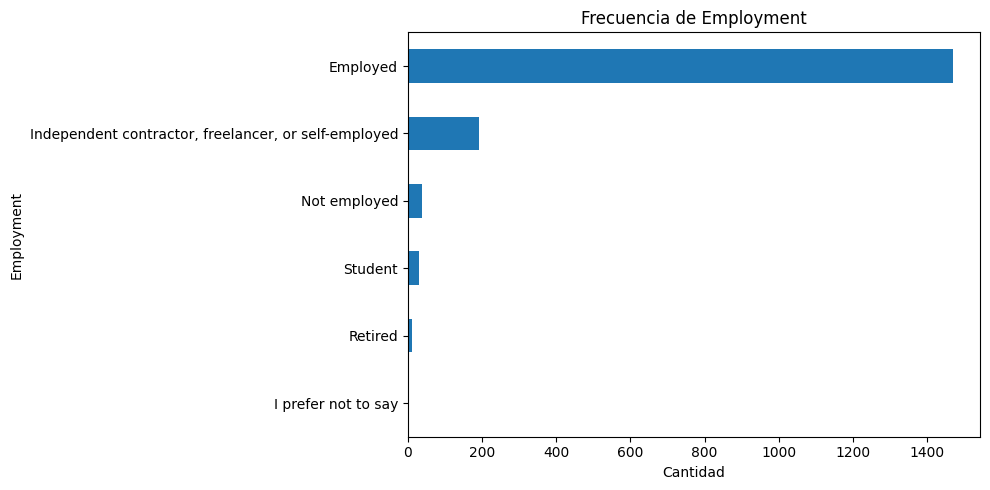


Variable categórica: AISelect
AISelect
Yes    1361
No      308
NaN      74
Name: count, dtype: int64

Porcentajes:
AISelect
Yes    78.08
No     17.67
NaN     4.25
Name: proportion, dtype: float64


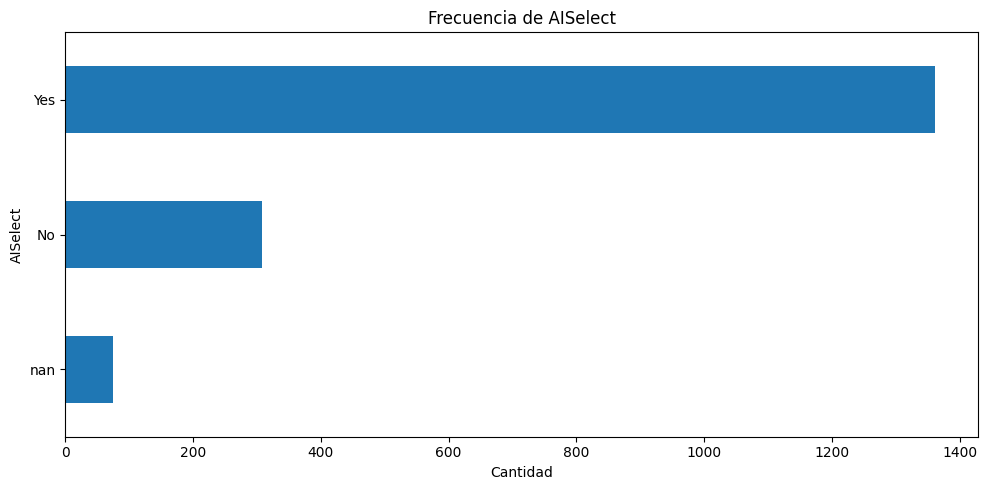


Variable categórica: Industry
Industry
Software Development                          583
Other:                                        198
Healthcare                                    125
Government                                    114
Banking/Financial Services                     96
Internet, Telecomm or Information Services     94
Manufacturing                                  75
Fintech                                        75
Energy                                         73
Retail and Consumer Services                   62
Transportation, or Supply Chain                61
Media & Advertising Services                   57
Computer Systems Design and Services           50
Higher Education                               43
Insurance                                      37
Name: count, dtype: int64

Porcentajes:
Industry
Software Development                          33.45
Other:                                        11.36
Healthcare                                     7.17
Gover

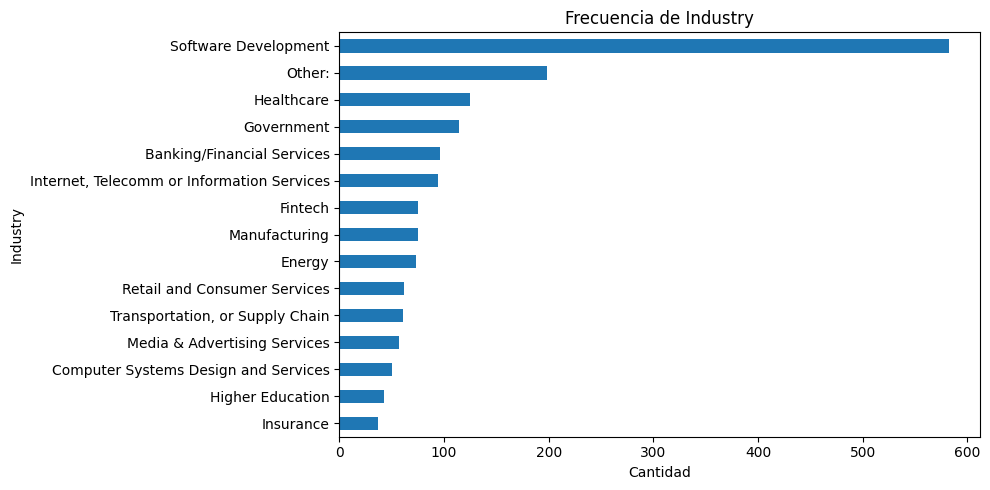


Variable categórica: Country
Country
United States of America                                444
Germany                                                 137
United Kingdom of Great Britain and Northern Ireland    112
India                                                    91
France                                                   89
                                                       ... 
Iceland                                                   1
Ghana                                                     1
Saudi Arabia                                              1
Moldova                                                   1
Paraguay                                                  1
Name: count, Length: 104, dtype: int64

Porcentajes:
Country
United States of America                                25.47
Germany                                                  7.86
United Kingdom of Great Britain and Northern Ireland     6.43
India                                                  

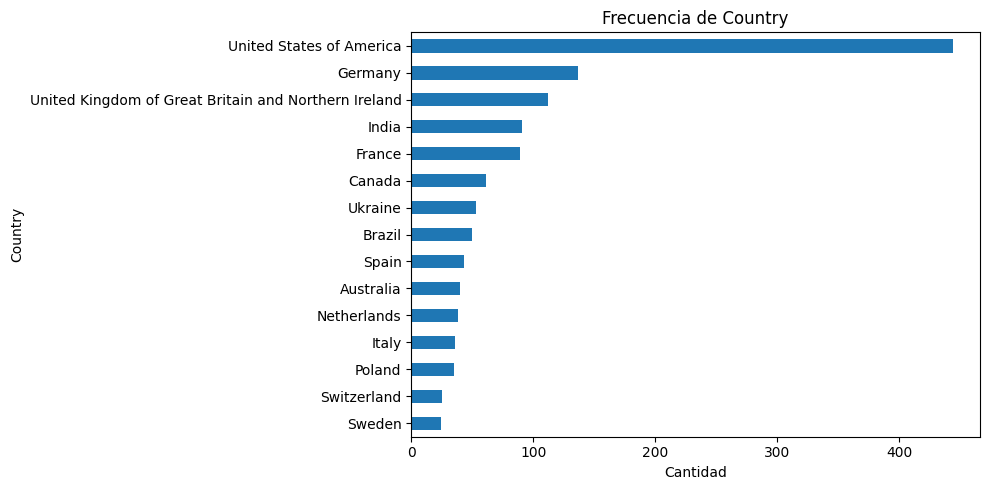


Variable categórica: DevType
DevType
Data engineer                         488
AI/ML engineer                        351
Data scientist                        345
Data or business analyst              185
Applied scientist                     162
Developer, AI apps or physical AI     113
Database administrator or engineer     99
Name: count, dtype: int64

Porcentajes:
DevType
Data engineer                         28.00
AI/ML engineer                        20.14
Data scientist                        19.79
Data or business analyst              10.61
Applied scientist                      9.29
Developer, AI apps or physical AI      6.48
Database administrator or engineer     5.68
Name: proportion, dtype: float64


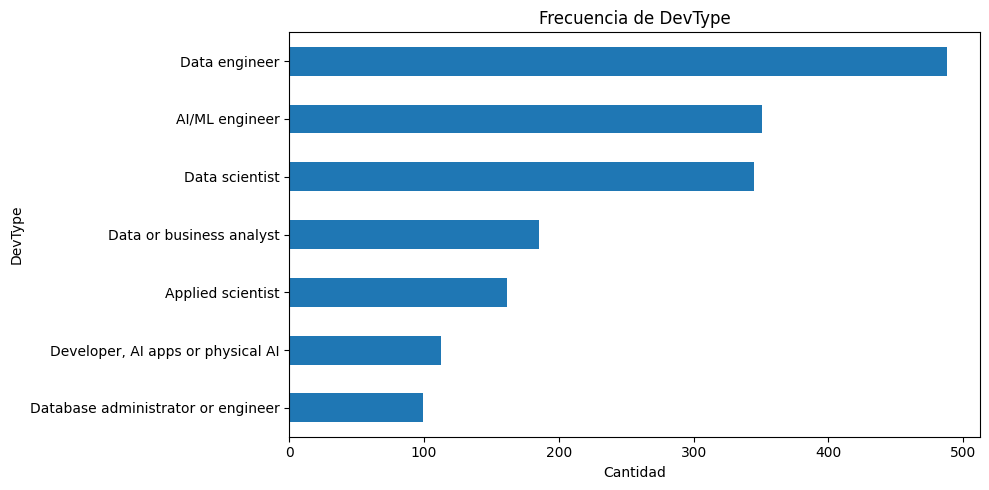

In [24]:
# 4. Frecuencias de variables categóricas

for col in categorical_cols:
    frecuencias = df_data_clean[col].value_counts(dropna=False)
    porcentajes = df_data_clean[col].value_counts(normalize=True, dropna=False) * 100

    print(f"\nVariable categórica: {col}")
    print(frecuencias)
    print("\nPorcentajes:")
    print(porcentajes.round(2))

    plt.figure(figsize=(10, 5))
    frecuencias.head(15).sort_values().plot(kind="barh")
    plt.title(f"Frecuencia de {col}")
    plt.xlabel("Cantidad")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

En el análisis de frecuencias de las variables categóricas se observa que la muestra está formada principalmente por personas de 25 a 44 años, que representan cerca del 69% del total. También destaca el alto nivel educativo de los encuestados, ya que más del 70% cuenta con estudios de máster o grado universitario.

En cuanto a la situación laboral, la mayoría de los registros corresponden a personas empleadas, con un 84,28%. Además, el 81,55% respondió afirmativamente en la variable `AISelect`, lo que indica una presencia elevada de perfiles relacionados con el uso o selección de inteligencia artificial.

Respecto a la industria, predomina `Software Development`, con un 33,45%. A nivel geográfico, Estados Unidos es el país más representado, con un 25,47%, aunque el dataset incluye participantes de 104 países. Finalmente, los perfiles profesionales más frecuentes son `Data engineer`, `AI/ML engineer` y `Data scientist`, lo que confirma que la muestra está muy orientada al ámbito de datos e inteligencia artificial.

In [27]:
# 5. Medidas de posición y rangos de variables numéricas

df_data_clean[numeric_cols].describe()

,ConvertedCompYearly,WorkExp,YearsCode,JobSat
count,1.743000e+03,1743.000000,1741.000000,1190.000000
mean,1.019077e+05,12.421113,15.668007,7.227731
std,1.557895e+05,9.867344,10.498279,1.953472
min,1.000000e+00,1.000000,1.000000,0.000000
25%,4.094650e+04,5.000000,8.000000,6.000000
50%,8.000000e+04,10.000000,13.000000,8.000000
75%,1.276465e+05,17.000000,20.000000,8.000000
max,4.706124e+06,50.000000,60.000000,10.000000


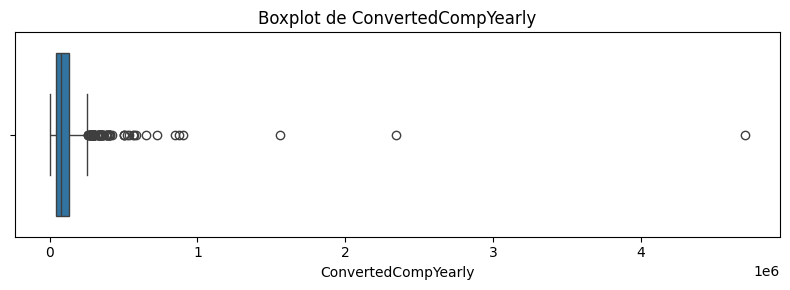

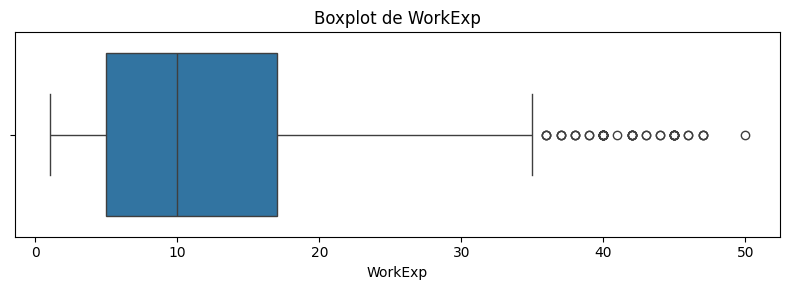

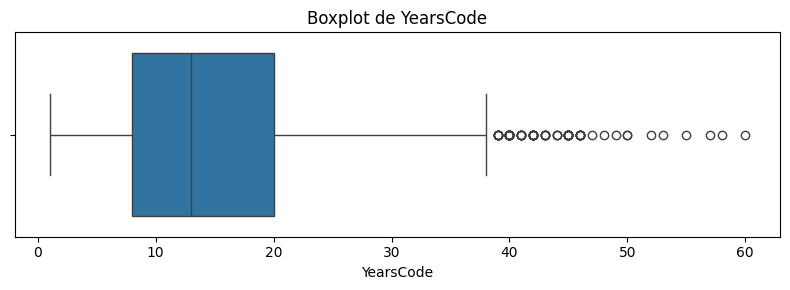

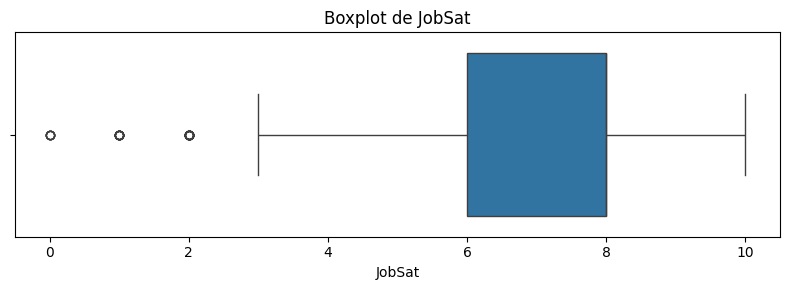

In [30]:
# 6. Gráficos de caja para variables numéricas

numeric_cols_clean = df_data_clean.select_dtypes(include="number").columns

for col in numeric_cols_clean:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_data_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Los gráficos de caja muestran diferencias importantes entre las variables numéricas. `ConvertedCompYearly` presenta una fuerte asimetría positiva, con varios valores atípicos altos que pueden influir en la media. `WorkExp` concentra la mayoría de observaciones entre 5 y 17 años, aunque aparecen valores elevados como outliers estadísticos.

En `YearsCode`, tras eliminar los valores anómalos de 100 años, la distribución resulta más coherente. La mayoría de registros se sitúa entre 8 y 20 años programando, aunque existen valores altos entre 40 y 60 años que pueden ser plausibles en perfiles de mayor edad. Por último, `JobSat` se concentra en valores altos de satisfacción, principalmente entre 6 y 8, mientras que los valores bajos aparecen como outliers pero son válidos dentro de la escala de 0 a 10.

In [31]:
# 7. Medidas de dispersión de variables numéricas

numeric_cols_clean = df_data_clean.select_dtypes(include="number").columns

dispersion = df_data_clean[numeric_cols_clean].agg(["std", "var", "min", "max"])

# Rango = máximo - mínimo
rango = df_data_clean[numeric_cols_clean].max() - df_data_clean[numeric_cols_clean].min()
dispersion.loc["range"] = rango

dispersion

,ConvertedCompYearly,WorkExp,YearsCode,JobSat
std,1.557895e+05,9.867344,10.498279,1.953472
var,2.427035e+10,97.364468,110.213855,3.816051
min,1.000000e+00,1.000000,1.000000,0.000000
max,4.706124e+06,50.000000,60.000000,10.000000
range,4.706123e+06,49.000000,59.000000,10.000000


Las medidas de dispersión muestran una variabilidad muy elevada en `ConvertedCompYearly`, con una desviación estándar de aproximadamente 155.789 y un rango de más de 4,7 millones. Esto confirma la presencia de valores extremos en la compensación anual, por lo que esta variable requiere una revisión más detallada en el análisis de outliers.

En `WorkExp` y `YearsCode` también existe dispersión, aunque dentro de rangos más interpretables. `WorkExp` varía entre 1 y 50 años, mientras que `YearsCode`, tras la limpieza inicial, varía entre 1 y 60 años. Por último, `JobSat` presenta un rango de 0 a 10, coherente con una escala de satisfacción laboral, y una desviación estándar moderada.

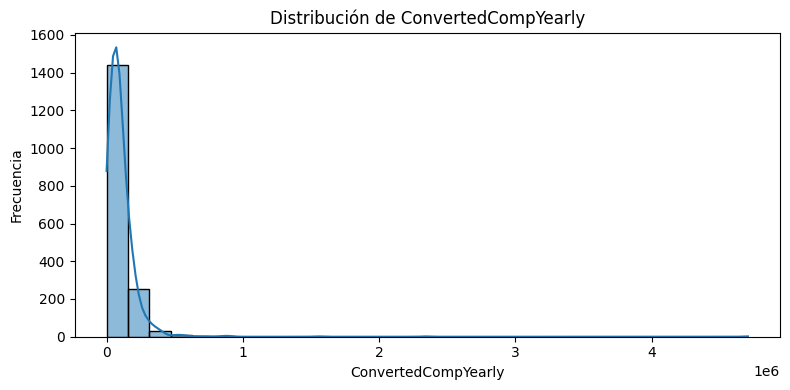

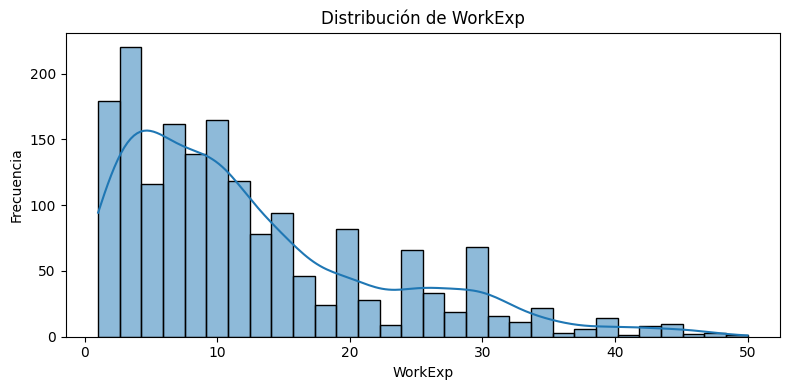

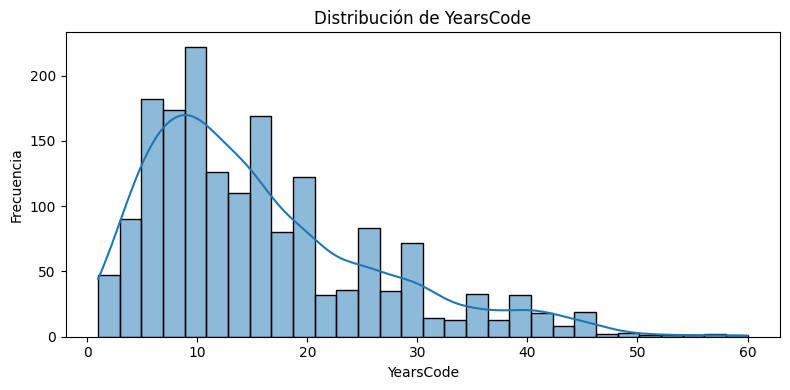

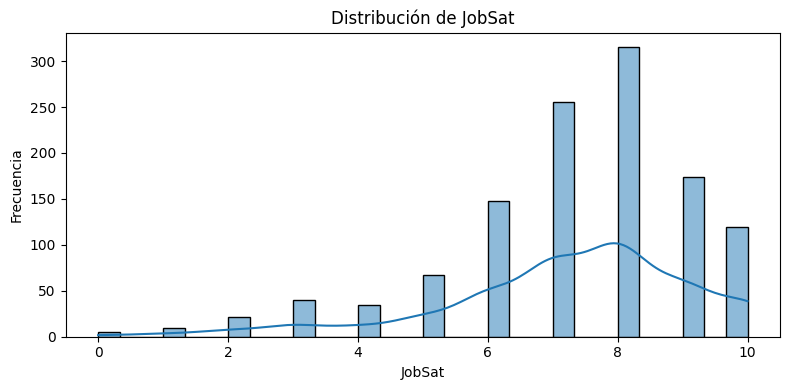

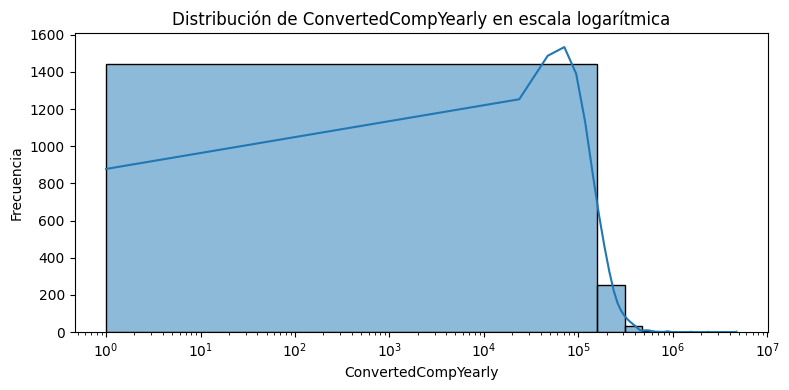

In [33]:
# 8. Distribuciones de variables numéricas
# Histogramas + KDE

for col in numeric_cols_clean:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_data_clean[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


# Distribución de ConvertedCompYearly en escala logarítmica
# Se usa para visualizar mejor la variable salario, ya que tiene valores extremos altos

plt.figure(figsize=(8, 4))
sns.histplot(df_data_clean["ConvertedCompYearly"], kde=True, bins=30)
plt.xscale("log")
plt.title("Distribución de ConvertedCompYearly en escala logarítmica")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Los histogramas muestran que `ConvertedCompYearly` tiene una distribución fuertemente asimétrica hacia la derecha, con la mayoría de salarios concentrados en rangos bajos o medios y algunos valores extremadamente altos. Por este motivo, se añade una visualización en escala logarítmica para interpretar mejor su distribución.

En `WorkExp`, la mayor parte de los registros se concentra entre los primeros años de experiencia y aproximadamente los 15 años, aunque existe una cola hacia valores más altos. `YearsCode` presenta un comportamiento similar, con mayor concentración entre 5 y 20 años programando y algunos valores elevados hasta 60 años.

Por último, `JobSat` se concentra principalmente en valores altos, especialmente entre 7 y 8, lo que sugiere una satisfacción laboral generalmente positiva dentro de la muestra.

In [34]:
# 9. Análisis de anomalías/outliers usando IQR

for col in numeric_cols_clean:
    Q1 = df_data_clean[col].quantile(0.25)
    Q3 = df_data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_data_clean[
        (df_data_clean[col] < limite_inferior) | 
        (df_data_clean[col] > limite_superior)
    ]

    print(f"\nVariable: {col}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")
    print(f"Número de outliers: {outliers.shape[0]}")
    print(f"Porcentaje de outliers: {round(outliers.shape[0] / df_data_clean.shape[0] * 100, 2)}%")


Variable: ConvertedCompYearly
Límite inferior: -89103.5
Límite superior: 257696.5
Número de outliers: 83
Porcentaje de outliers: 4.76%

Variable: WorkExp
Límite inferior: -13.0
Límite superior: 35.0
Número de outliers: 48
Porcentaje de outliers: 2.75%

Variable: YearsCode
Límite inferior: -10.0
Límite superior: 38.0
Número de outliers: 88
Porcentaje de outliers: 5.05%

Variable: JobSat
Límite inferior: 3.0
Límite superior: 11.0
Número de outliers: 37
Porcentaje de outliers: 2.12%


El análisis de outliers mediante el método IQR confirma la presencia de valores atípicos en todas las variables numéricas. En `ConvertedCompYearly`, se detectan 83 outliers, equivalentes al 4,76% del dataset, correspondientes a compensaciones anuales superiores a 257.696,5. Estos valores explican la fuerte asimetría observada en histogramas y boxplots.

En `WorkExp`, se identifican 48 outliers por encima de 35 años de experiencia, mientras que en `YearsCode` se detectan 88 outliers por encima de 38 años programando. Estos casos no tienen por qué ser errores, ya que pueden corresponder a perfiles profesionales muy senior.

Por último, en `JobSat` se detectan 37 outliers, equivalentes al 2,12%, correspondientes a valores inferiores a 3. Dado que la variable está definida en una escala de 0 a 10, estos valores se consideran válidos y representan niveles bajos de satisfacción laboral.